# Feature Engineering Analysis
We extract CNN feature vectors from the final trained model and visualize the learned feature space using t-SNE to assess class separability.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

In [7]:
PROJECT_ROOT = Path("../").resolve()
DATA_DIR = PROJECT_ROOT / "data"
ORGANIZED_DIR = DATA_DIR / "organized"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models"

IMG_SIZE = 256
BATCH_SIZE = 64
CLASS_NAMES = ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']

## 1. Load Final Model and Build Feature Extractor

In [8]:
model_dir = MODELS_DIR / "final"

keras_path = model_dir / "best_model.keras"
h5_path = model_dir / "best_model.h5"

if keras_path.exists():
    model_path = keras_path
elif h5_path.exists():
    model_path = h5_path
else:
    raise FileNotFoundError("Best model not found (.keras or .h5)")

final_model = keras.models.load_model(str(model_path))

print(f"Model loaded from {model_path.name}. Layers: {len(final_model.layers)}")

I0000 00:00:1772654942.679245  558704 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13294 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:01:00.0, compute capability: 8.9
2026-03-04 20:09:05.139701: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


Model loaded from best_model.h5. Layers: 344


In [9]:
# The layer before the final Dense is GlobalAveragePooling or Dropout
# We use the penultimate dense input as features
feature_layer_name = [l.name for l in final_model.layers if 'dropout' in l.name][-1]
print(f"Feature extraction layer: {feature_layer_name}")

feature_model = keras.Model(
    inputs=final_model.input,
    outputs=final_model.get_layer(feature_layer_name).output
)

Feature extraction layer: top_dropout


## 2. Extract Features from Test Set

In [10]:
test_ds = keras.utils.image_dataset_from_directory(
    ORGANIZED_DIR / "test",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False
).prefetch(tf.data.AUTOTUNE)

features, labels = [], []
for imgs, lbls in test_ds:
    feats = feature_model(imgs, training=False)
    features.append(feats.numpy())
    labels.extend(lbls.numpy())

X = np.vstack(features)
y = np.array(labels)
print(f"Feature matrix: {X.shape}")

Found 1503 files belonging to 7 classes.


2026-03-04 20:09:09.493476: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


Feature matrix: (1503, 1408)


2026-03-04 20:09:30.239114: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 3. t-SNE Visualization
We first reduce to 50 dimensions with PCA (faster and more stable for t-SNE), then apply t-SNE to 2D.

In [11]:
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X)
print(f"PCA variance explained (50 components): {pca.explained_variance_ratio_.sum():.3f}")

PCA variance explained (50 components): 0.793


In [13]:
tsne = TSNE(n_components=2, perplexity=40, random_state=42, max_iter=1000)
X_2d = tsne.fit_transform(X_pca)
print(f"t-SNE complete. Shape: {X_2d.shape}")

t-SNE complete. Shape: (1503, 2)


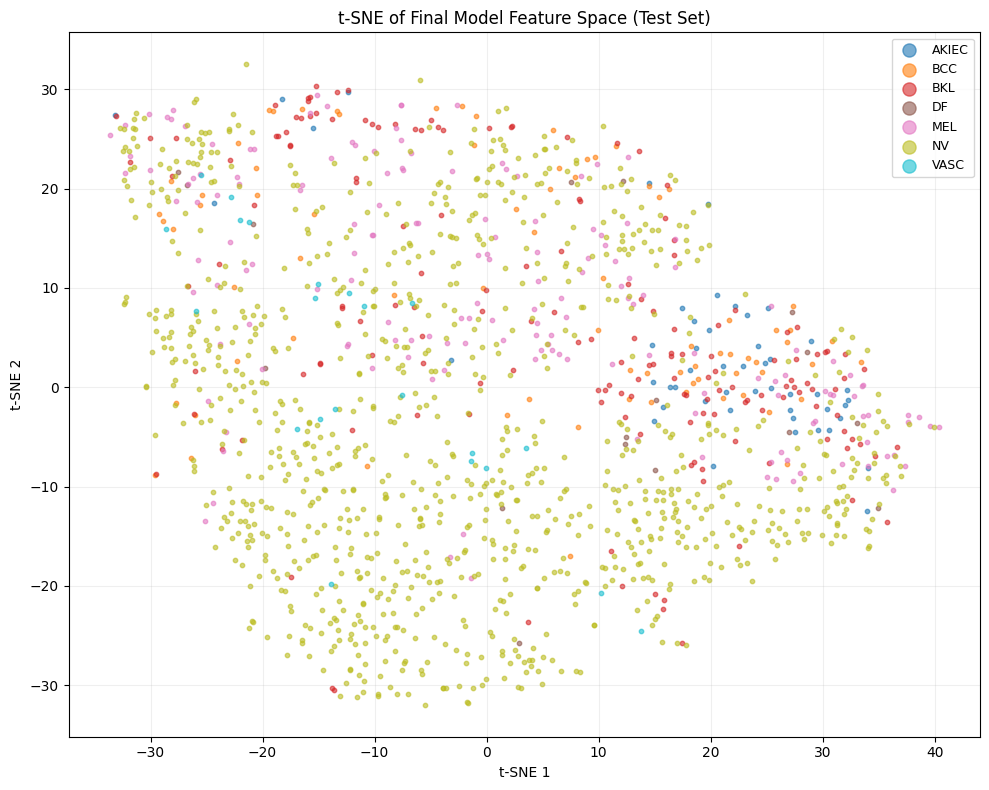

In [14]:
colors = plt.cm.tab10(np.linspace(0, 1, len(CLASS_NAMES)))

fig, ax = plt.subplots(figsize=(10, 8))
for idx, (cls, color) in enumerate(zip(CLASS_NAMES, colors)):
    mask = y == idx
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], s=10, color=color, label=cls, alpha=0.6)

ax.legend(markerscale=3, fontsize=9)
ax.set_title("t-SNE of Final Model Feature Space (Test Set)")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "tsne_feature_space.png", dpi=150, bbox_inches="tight")
plt.show()

Well-separated clusters per class indicate the model has learned discriminative features. Overlapping clusters (typically between visually similar classes like MEL/NV or AK/BKL) reveal remaining classification difficulty.

## 4. Class Separability — Inter-class Distance

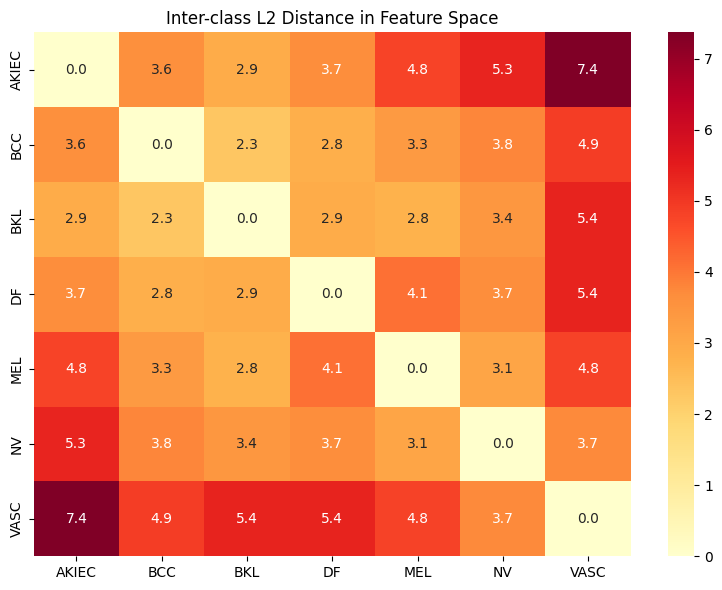

In [15]:
# Mean feature vector per class
class_means = np.array([X[y == i].mean(axis=0) for i in range(len(CLASS_NAMES))])

# Pairwise L2 distances
from sklearn.metrics.pairwise import euclidean_distances
dist_matrix = euclidean_distances(class_means)

import pandas as pd
dist_df = pd.DataFrame(dist_matrix, index=CLASS_NAMES, columns=CLASS_NAMES)

plt.figure(figsize=(8, 6))
import seaborn as sns
sns.heatmap(dist_df, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title("Inter-class L2 Distance in Feature Space")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "inter_class_distance.png", dpi=150, bbox_inches="tight")
plt.show()

Large distances indicate well-separated classes. Classes with small inter-class distances are likely to be confused with each other in classification.

In [16]:
np.save(RESULTS_DIR / "test_features.npy", X)
np.save(RESULTS_DIR / "test_labels.npy",   y)
print("Features and labels saved.")

Features and labels saved.
